# Assignment 4 EDA and Preprocessing

- Name: Kenji Otsuka
- Email: kotsuka@umich.edu

In this notebook, I performed exploratory data analysis (EDA) and preprocessing on the data, after creating data using fitparse_csv_creation.ipynb. In preprocessing, I categorized the data into running and cycling, and added `activity_type` column and saved the data as a new CSV file.

## Adherence to Rule et al.'s "Ten Simple Rules for Writing and Sharing Computational Analyses in Jupyter Notebooks"

### Rule 1: Tell a Story for an Audience

This notebook explains how Professor Brooks' running performance has changed over time.
Each section provides not just the calculations, but also the practical context behind them.
The statements contains insights, rather than just technical detail.

### Rule 2: Document the Process, Not Just the Results

I documented intermediate steps, exploratory attempts, and reasoning behind parameter choices in addition to the final results.
I included short markdown notes that describe why a particular approach was tried and what insights it provided.

### Rule 3: Use Cell Divisions to Make Steps Clear

Each cell performs one meaningful step of the analysis, such as loading data, computing a statistic, generating a plot, or performing clustering.
Markdown headers divide the notebook into clear sections (e.g., preprocessing, exploratory analysis, correlation analysis, clustering), and each cell is preceded by a short explanation of its purpose.


## Explorative Data Analysis

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score
import numpy as np

In [2]:
df = pd.read_csv("/voc/work/csv_output/combined.csv")

Check types and value counts.

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 529985 entries, 0 to 529984
Data columns (total 24 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   altitude              14905 non-null   float64
 1   cadence               529150 non-null  float64
 2   distance              529985 non-null  float64
 3   enhanced_altitude     501805 non-null  float64
 4   enhanced_speed        529232 non-null  float64
 5   fractional_cadence    529150 non-null  float64
 6   heart_rate            526547 non-null  float64
 7   position_lat          496082 non-null  float64
 8   position_long         496082 non-null  float64
 9   speed                 14928 non-null   float64
 10  timestamp             529985 non-null  object 
 11  unknown_87            505969 non-null  float64
 12  unknown_88            344883 non-null  float64
 13  source_file           529985 non-null  object 
 14  Cadence               484751 non-null  float64
 15  

Show correlation between variables

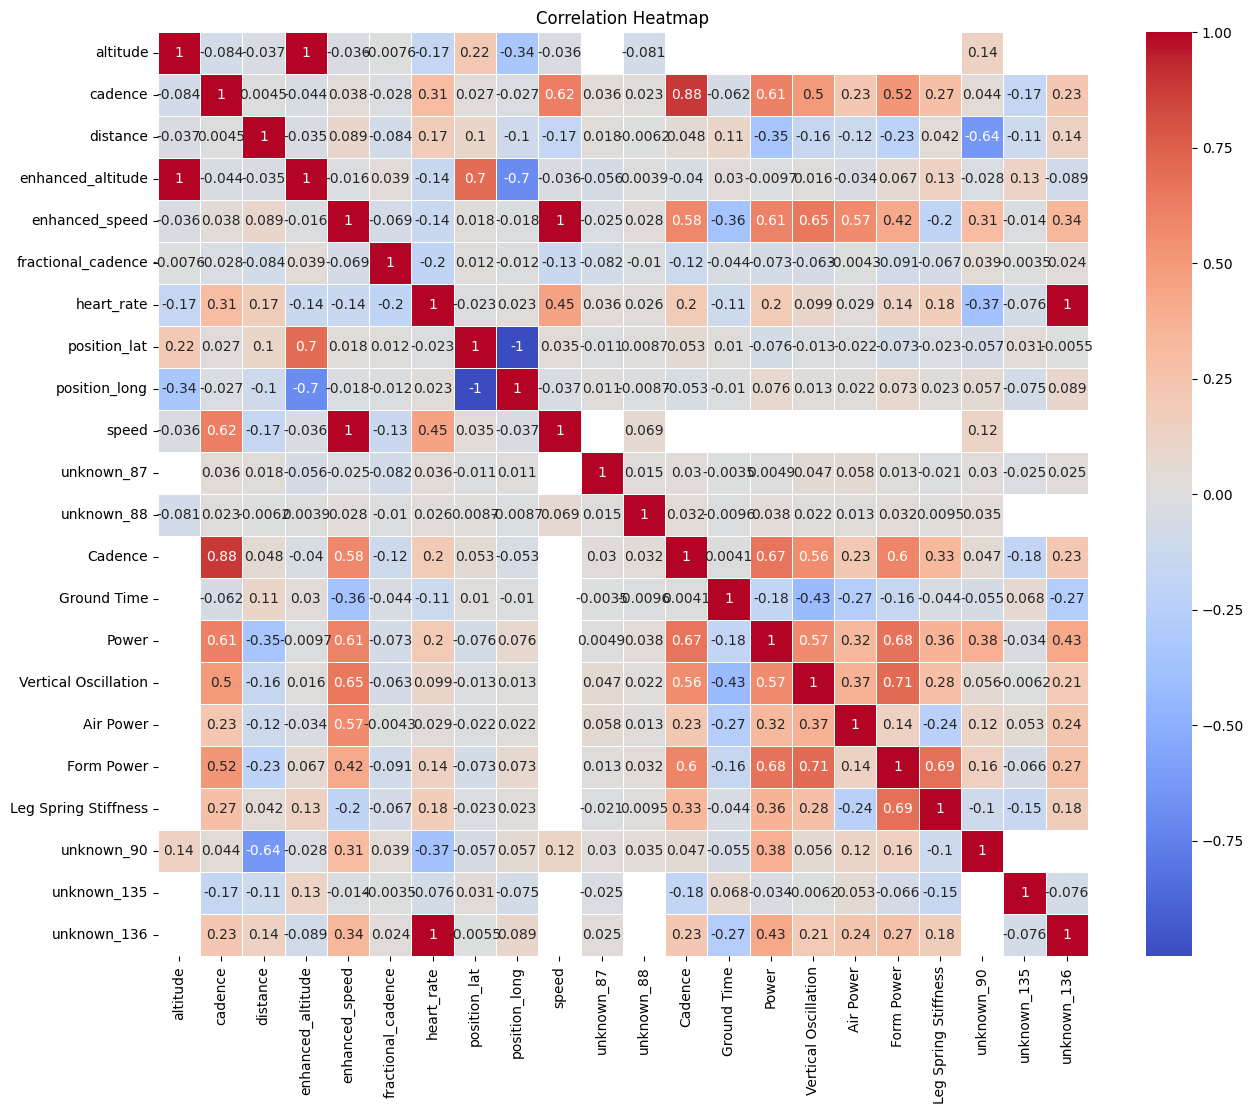

In [4]:
plt.figure(figsize=(15, 12))
codf = df.select_dtypes(include=["float64", "int64"])
sns.heatmap(codf.corr(), annot=True, cmap="coolwarm", linewidths=0.5)
plt.title("Correlation Heatmap")
plt.show()

## Remove Duplicating and Meaningless Columns

Unknown columns are added because of the device system, not meaningful. So drop them.

In [5]:
df.drop(columns=["unknown_87", "unknown_88", "unknown_90", "unknown_135", "unknown_136"], inplace=True)
df.columns


Index(['altitude', 'cadence', 'distance', 'enhanced_altitude',
       'enhanced_speed', 'fractional_cadence', 'heart_rate', 'position_lat',
       'position_long', 'speed', 'timestamp', 'source_file', 'Cadence',
       'Ground Time', 'Power', 'Vertical Oscillation', 'Air Power',
       'Form Power', 'Leg Spring Stiffness'],
      dtype='object')

Confirm that enhanced_speed covers all rows with speed values.

In [6]:
print(
    "Number of rows where speed is not null but enhanced_speed is null:",
    df[df["speed"].notnull() & df["enhanced_speed"].isnull()].shape[0],
)

Number of rows where speed is not null but enhanced_speed is null: 0


Then, speed column can be dropped.

Confirm that enhanced_altitude covers all rows with altitude values

In [7]:
print(
    "Number of rows where altitude is not null but enhanced_altitude is null:",
    df[df["altitude"].notnull() & df["enhanced_altitude"].isnull()].shape[0],
)

Number of rows where altitude is not null but enhanced_altitude is null: 0


Check cadence and Cadence relation.

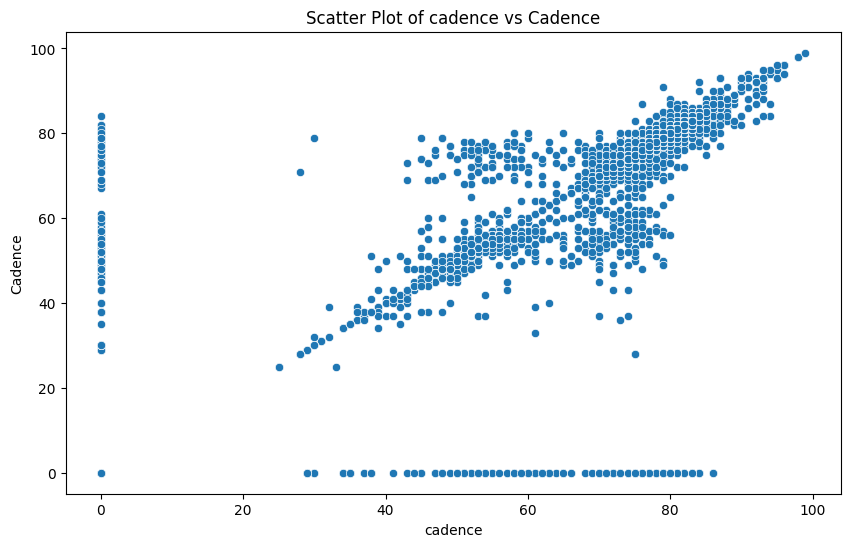

In [8]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x="cadence", y="Cadence", data=df)
plt.title("Scatter Plot of cadence vs Cadence")
plt.xlabel("cadence")
plt.ylabel("Cadence")
plt.show()


Some record has zero cadence and non-zero Cadence, also some record has non-zero cadence and zero Cadence.

See more details.

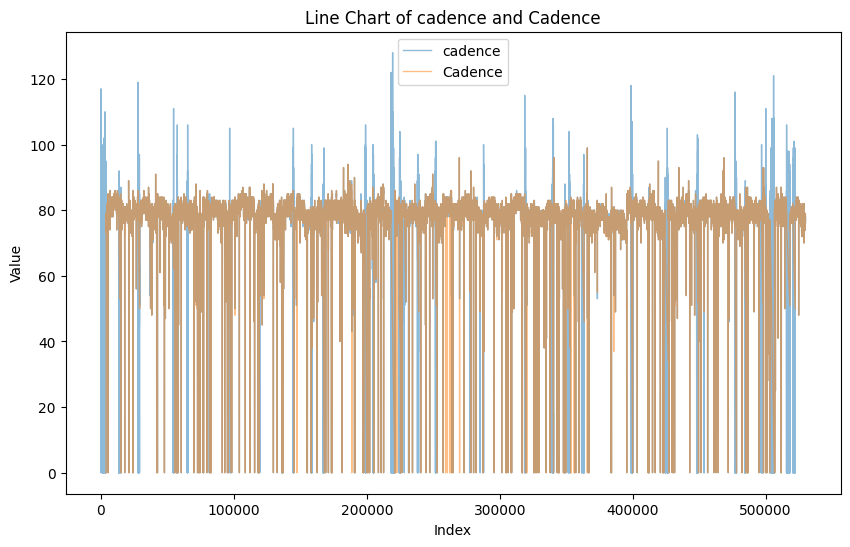

In [9]:
plt.figure(figsize=(10, 6))
sns.lineplot(x=df.index, y="cadence", linewidth=1, data=df, label="cadence", alpha=0.5)
sns.lineplot(x=df.index, y="Cadence", linewidth=1, data=df, label="Cadence", alpha=0.5)
plt.title("Line Chart of cadence and Cadence")
plt.xlabel("Index")
plt.ylabel("Value")
plt.legend()
plt.show()

They are not the same, but if the records that have null Cadence and non-null cadence, Cadence can be dropped for the records.

Confirm that cadence covers Cadence values. If cadence is not null for all records where Cadence is not null, Cadence can be dropped.

In [10]:
print(
    "Number of rows where Cadence is not null but cadence is null:",
    df[df["Cadence"].notnull() & df["cadence"].isnull()].shape[0],
)
print(
    "Number of rows where cadence is not null but Cadence is null:",
    df[df["cadence"].notnull() & df["Cadence"].isnull()].shape[0],
)

Number of rows where Cadence is not null but cadence is null: 0
Number of rows where cadence is not null but Cadence is null: 44399


Drop Cadence, speed and altitude because they are covered by cadence, enhanced_speed and enhanced_altitude

In [11]:
df.drop(columns=["Cadence", "speed", "altitude"], inplace=True)
df.columns


Index(['cadence', 'distance', 'enhanced_altitude', 'enhanced_speed',
       'fractional_cadence', 'heart_rate', 'position_lat', 'position_long',
       'timestamp', 'source_file', 'Ground Time', 'Power',
       'Vertical Oscillation', 'Air Power', 'Form Power',
       'Leg Spring Stiffness'],
      dtype='object')

Again, see correlation between variables after dropping redundant columns

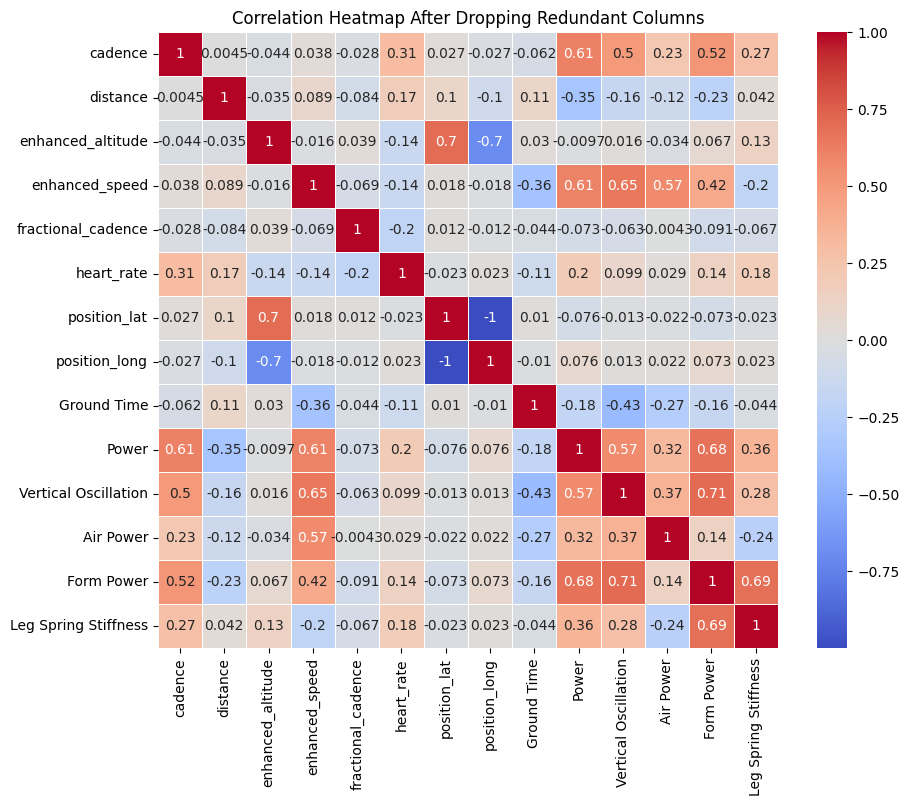

In [12]:
plt.figure(figsize=(10, 8))
codf = df.select_dtypes(include=["float64", "int64"])
sns.heatmap(codf.corr(), annot=True, cmap="coolwarm", linewidths=0.5)
plt.title("Correlation Heatmap After Dropping Redundant Columns")
plt.show()

Remarkablly, position_lat and position_long are highly correlated. Also, enhanced_altitude highly correlates them. See the actual value.

In [13]:
correlation = df["position_lat"].corr(df["position_long"])
print(f"Correlation coefficient between position_lat and position_long: {correlation}")

Correlation coefficient between position_lat and position_long: -0.9999982690437398


Draw and see a scatter plot of position_lat and position_long

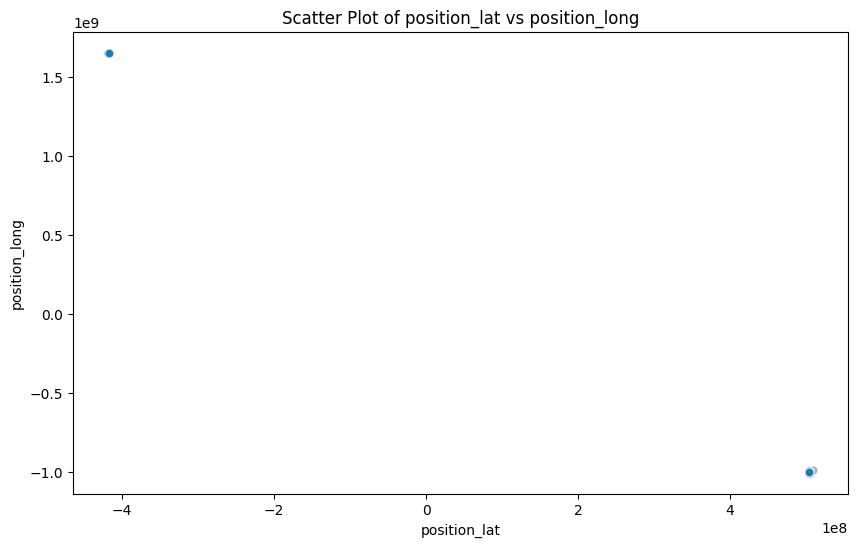

In [14]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x="position_lat", y="position_long", data=df, alpha=0.5)
plt.title("Scatter Plot of position_lat vs position_long")
plt.xlabel("position_lat")
plt.ylabel("position_long")
plt.show()

The athlete, Dr. Brooks, worked in 2 distant positions. Some records are in concentrate on one position, and the other records concentrate on another position. Numerically the correlation is high but it is not an actual data relation. It is also the reason of coefficients among position_lat position_long, and enhanced_altitude.

## Check Distribution

See the distribution of each variable, to understand the data better.

In [15]:
#df.columns

convert timestamp

In [16]:
df["timestamp"] = pd.to_datetime(df["timestamp"])
df["timestamp"].head()

0   2019-07-14 17:20:28
1   2019-07-14 17:20:29
2   2019-07-14 17:20:30
3   2019-07-14 17:20:33
4   2019-07-14 17:20:34
Name: timestamp, dtype: datetime64[ns]

See distribution of Enhanced Speed, Form Power Leg Spring Stiffness cadence, Ground Time, Power, Vertical Oscillation, heart_rate

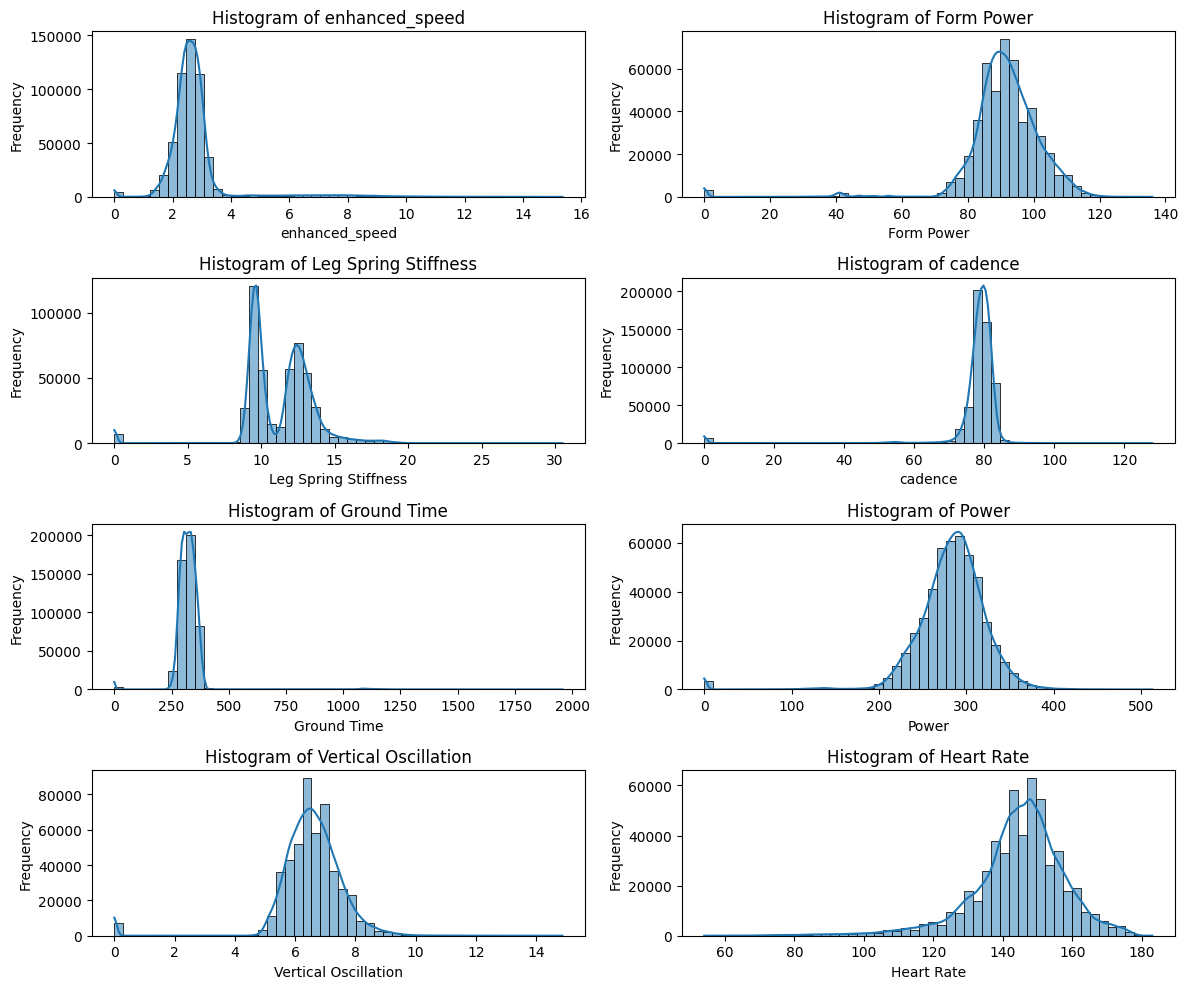

In [17]:
plt.figure(figsize=(12, 10))

plt.subplot(4, 2, 1)
sns.histplot(df["enhanced_speed"], bins=50, kde=True)
plt.title("Histogram of enhanced_speed")
plt.xlabel("enhanced_speed")
plt.ylabel("Frequency")

plt.subplot(4, 2, 2)
sns.histplot(df["Form Power"], bins=50, kde=True)
plt.title("Histogram of Form Power")
plt.xlabel("Form Power")
plt.ylabel("Frequency")

plt.subplot(4, 2, 3)
sns.histplot(df["Leg Spring Stiffness"], bins=50, kde=True)
plt.title("Histogram of Leg Spring Stiffness")
plt.xlabel("Leg Spring Stiffness")
plt.ylabel("Frequency")

plt.subplot(4, 2, 4)
sns.histplot(df["cadence"], bins=50, kde=True)
plt.title("Histogram of cadence")
plt.xlabel("cadence")
plt.ylabel("Frequency")

plt.subplot(4, 2, 5)
sns.histplot(df["Ground Time"], bins=50, kde=True)
plt.title("Histogram of Ground Time")
plt.xlabel("Ground Time")
plt.ylabel("Frequency")

plt.subplot(4, 2, 6)
sns.histplot(df["Power"], bins=50, kde=True)
plt.title("Histogram of Power")
plt.xlabel("Power")
plt.ylabel("Frequency")

plt.subplot(4, 2, 7)
sns.histplot(df["Vertical Oscillation"], bins=50, kde=True)
plt.title("Histogram of Vertical Oscillation")
plt.xlabel("Vertical Oscillation")
plt.ylabel("Frequency")

plt.subplot(4, 2, 8)
sns.histplot(df["heart_rate"], bins=50, kde=True)
plt.title("Histogram of Heart Rate")
plt.xlabel("Heart Rate")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()


## Categorize Running and Cycling

The data contains both running and cycling records.
I supposed each `.fit` file contains either running or cycling records, not both, because one `.fit` file represents one activity.

For categorizing running and cycling, I tried to summrize `.fit` file summaries, such as max speed, max cadence, max power, and max heart_rate.

In [34]:
metrics = ["max", "median", "mean"]
target_columns = [
    "enhanced_speed",
    "Form Power",
    "Leg Spring Stiffness",
    "cadence",
    "Ground Time",
    "Power",
    "Vertical Oscillation",
    "heart_rate",
]
params = {col: metrics for col in target_columns}
grouped_df = df.groupby("source_file").agg(params)
grouped_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 199 entries, 2675855419.fit to 4491335236.fit
Data columns (total 24 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   (enhanced_speed, max)           198 non-null    float64
 1   (enhanced_speed, median)        198 non-null    float64
 2   (enhanced_speed, mean)          198 non-null    float64
 3   (Form Power, max)               120 non-null    float64
 4   (Form Power, median)            120 non-null    float64
 5   (Form Power, mean)              120 non-null    float64
 6   (Leg Spring Stiffness, max)     120 non-null    float64
 7   (Leg Spring Stiffness, median)  120 non-null    float64
 8   (Leg Spring Stiffness, mean)    120 non-null    float64
 9   (cadence, max)                  198 non-null    float64
 10  (cadence, median)               198 non-null    float64
 11  (cadence, mean)                 198 non-null    float64
 12  (Ground Time, max

In [19]:
grouped_df.head()

enhanced_speed                   Form Power              \
                          max  median      mean        max median mean   
source_file                                                              
2675855419.fit          3.144  2.2110  2.088154        NaN    NaN  NaN   
2677658978.fit          3.210  2.7385  2.618897        NaN    NaN  NaN   
2677658993.fit          2.781  2.6970  2.683778        NaN    NaN  NaN   
2677659014.fit          2.781  2.4260  2.437679        NaN    NaN  NaN   
2682705331.fit          3.480  1.9780  1.966212        NaN    NaN  NaN   

               Leg Spring Stiffness             cadence  ... Ground Time  \
                                max median mean     max  ...        mean   
source_file                                              ...               
2675855419.fit                  NaN    NaN  NaN    88.0  ...         NaN   
2677658978.fit                  NaN    NaN  NaN    84.0  ...         NaN   
2677658993.fit                  NaN    NaN  NaN    84.0  ...         NaN   
2677659014.fit                  NaN    NaN  NaN    82.0  ...         NaN   
2682705331.fit                  NaN    NaN  NaN    81.0  ...         NaN   

               Power             Vertical Oscillation             heart_rate  \
                 max median mean                  max median mean        max   
source_file                                                                    
2675855419.fit   NaN    NaN  NaN                  NaN    NaN  NaN      137.0   
2677658978.fit   NaN    NaN  NaN                  NaN    NaN  NaN      137.0   
2677658993.fit   NaN    NaN  NaN                  NaN    NaN  NaN      143.0   
2677659014.fit   NaN    NaN  NaN                  NaN    NaN  NaN      139.0   
2682705331.fit   NaN    NaN  NaN                  NaN    NaN  NaN      126.0   

                                   
               median        mean  
source_file                        
2675855419.fit  121.0  118.337398  
2677658978.fit  130.0  122.117647  
2677658993.fit  137.0  135.592593  
2677659014.fit  136.0  134.571429  
2682705331.fit  119.0  117.687157  

[5 rows x 24 columns]

See the distribution of max values.

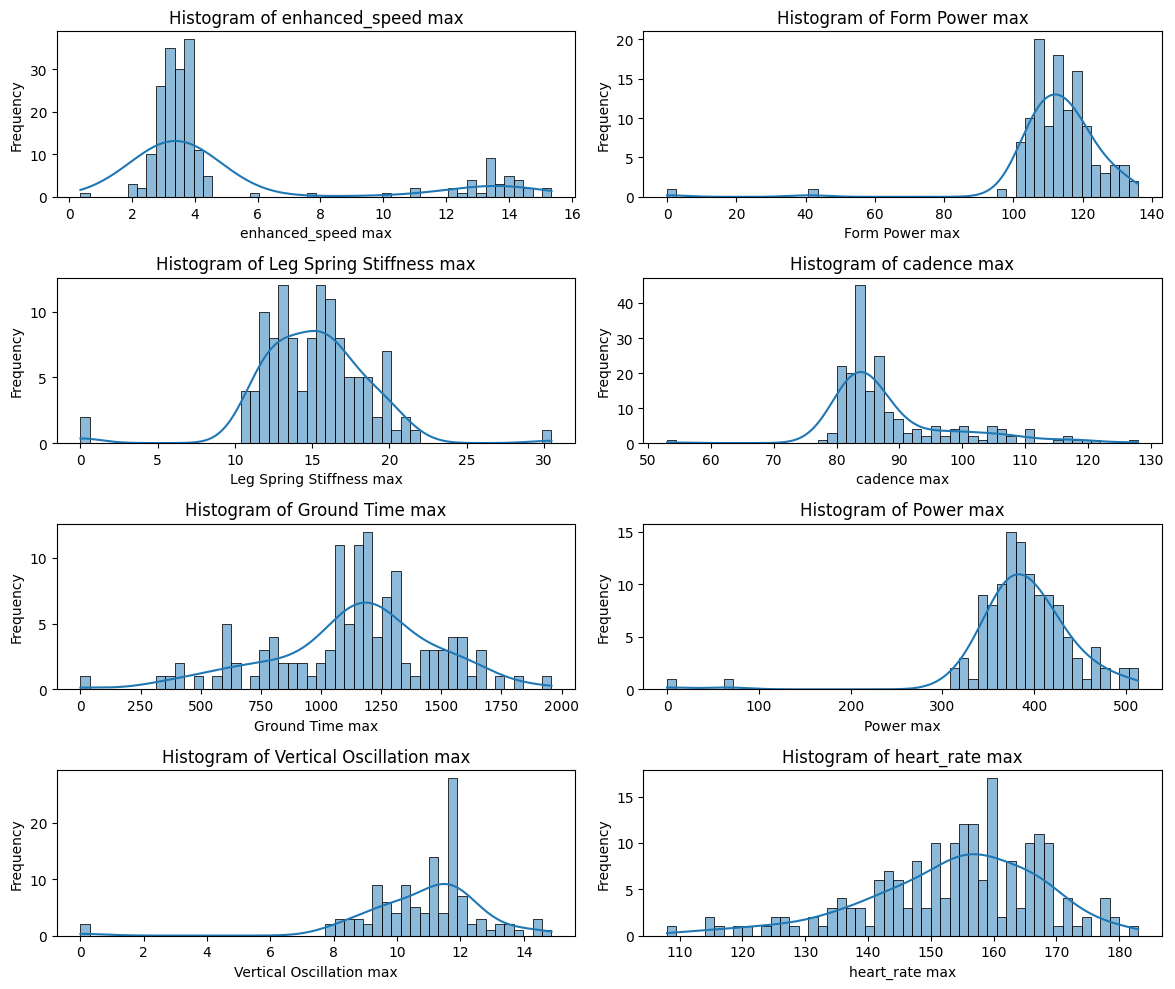

In [20]:
plt.figure(figsize=(12, 10))
for i, col in enumerate(target_columns):
    plt.subplot(4, 2, i + 1)
    sns.histplot(grouped_df[col]["max"], bins=50, kde=True)
    plt.title(f"Histogram of {col} max")
    plt.xlabel(f"{col} max")
    plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

See the distribution of median.

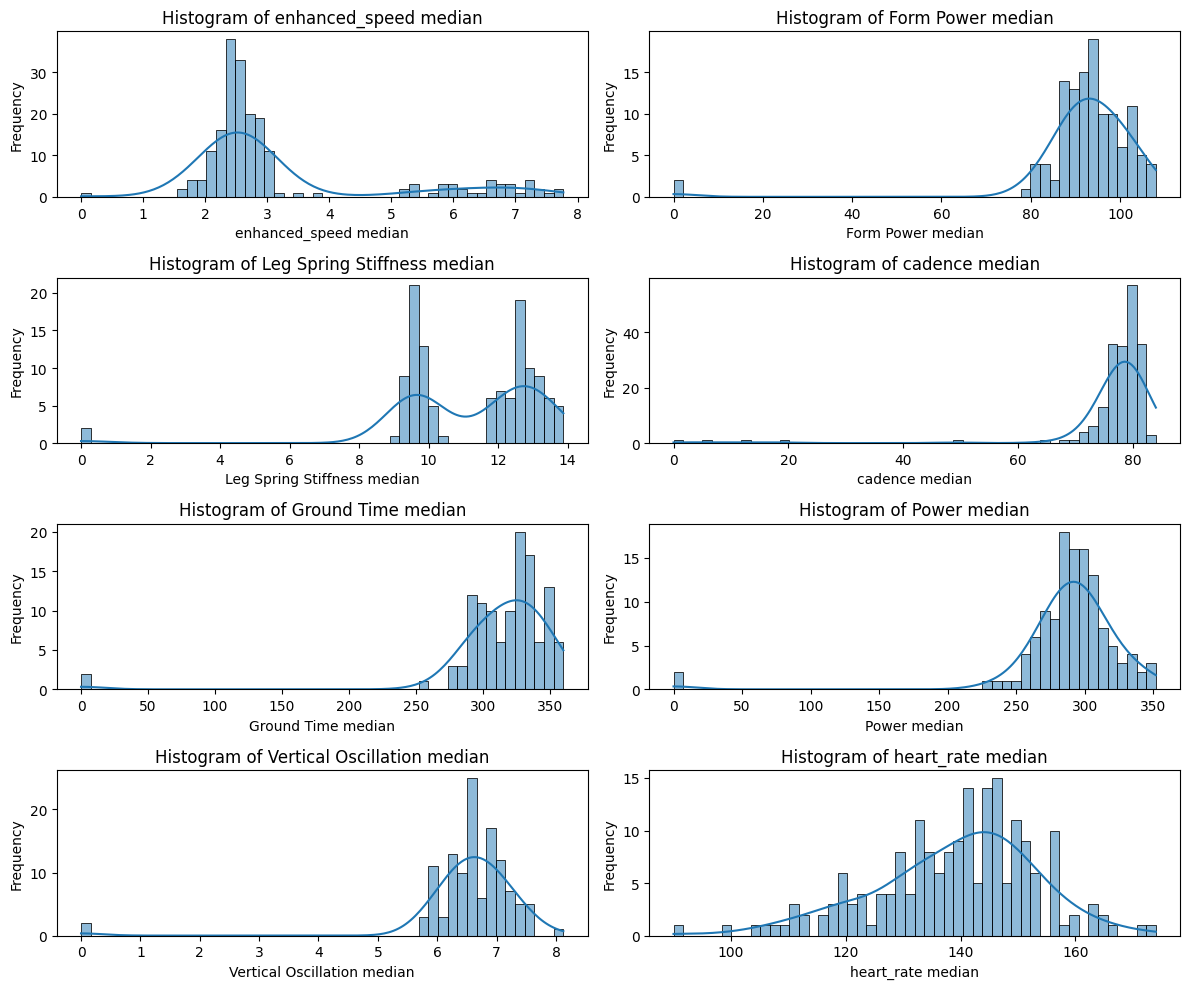

In [21]:
plt.figure(figsize=(12, 10))
for i, col in enumerate(target_columns):
    plt.subplot(4, 2, i + 1)
    sns.histplot(grouped_df[col]["median"], bins=50, kde=True)
    plt.title(f"Histogram of {col} median")
    plt.xlabel(f"{col} median")
    plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

Categorize the data in 2 steps.

First, categorize the data by max speed. If max speed is too fast, it can be concluded that the activity is cycling. If max speed is too slow, it can be concluded that the activity is running. 
Here, I categorized in the following rule

- max enhanced_speed >= 10 m/s: cycling
- max enhanced_speed < 4 m/s: running
- other: unknown

Then, use machinelearning model for categorizing, because some data could have irregular patterns and it is not easy to categorize the data by max speed only.
Learn a model with categorized data, and predict the uncategorized data. Here, I used RandomForestClassifier.

In [22]:
def classify_activity(row):
    if row["enhanced_speed"]["max"] < 4.0:
        return "running"
    elif row["enhanced_speed"]["max"] > 10.0:
        return "cycling"
    else:
        return "unknown"

grouped_df["activity_type"] = grouped_df.apply(classify_activity, axis=1)


See the distribution categorized by max speed.

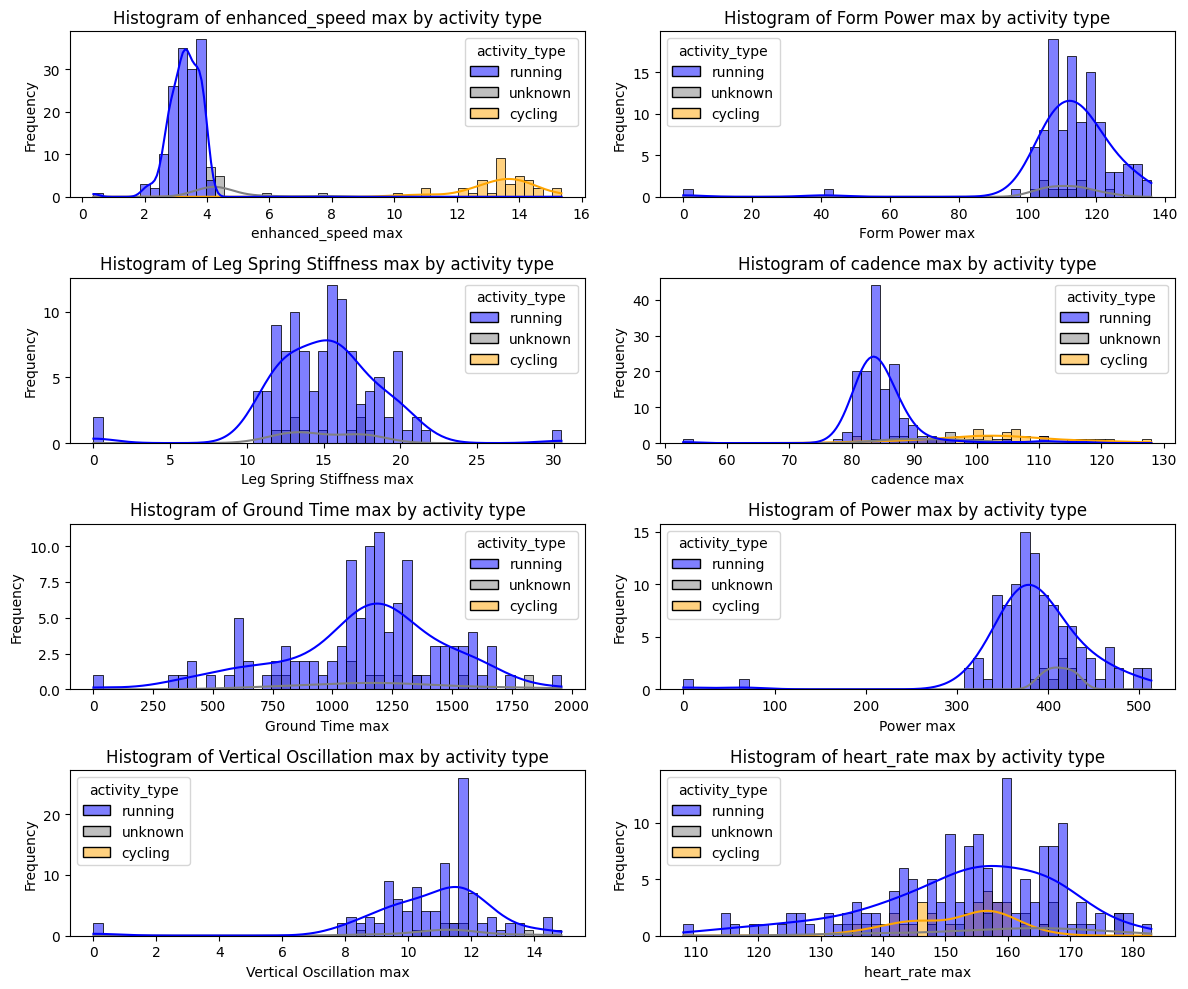

In [23]:
plt.figure(figsize=(12, 10))
for i, col in enumerate(target_columns):
    plt.subplot(4, 2, i + 1)
    sns.histplot(
        x=grouped_df[col]["max"],
        hue=grouped_df["activity_type"],
        bins=50,
        kde=True,
        palette={"running": "blue", "cycling": "orange", "unknown": "gray"},
    )
    plt.title(f"Histogram of {col} max by activity type")
    plt.xlabel(f"{col} max")
    plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

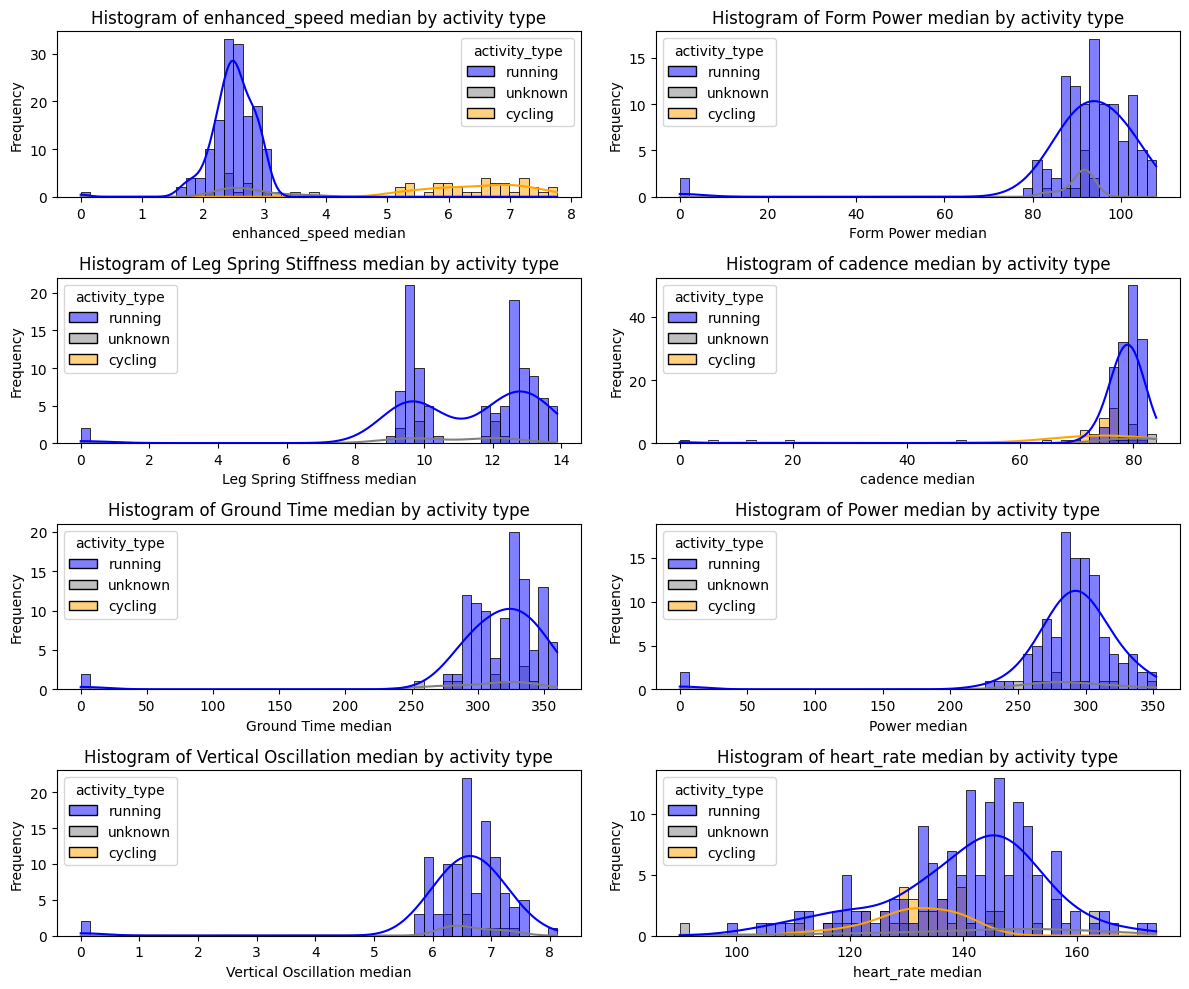

In [24]:
plt.figure(figsize=(12, 10))
for i, col in enumerate(target_columns):
    plt.subplot(4, 2, i + 1)
    sns.histplot(
        x=grouped_df[col]["median"],
        hue=grouped_df["activity_type"],
        bins=50,
        kde=True,
        palette={"running": "blue", "cycling": "orange", "unknown": "gray"},
    )
    plt.title(f"Histogram of {col} median by activity type")
    plt.xlabel(f"{col} median")
    plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

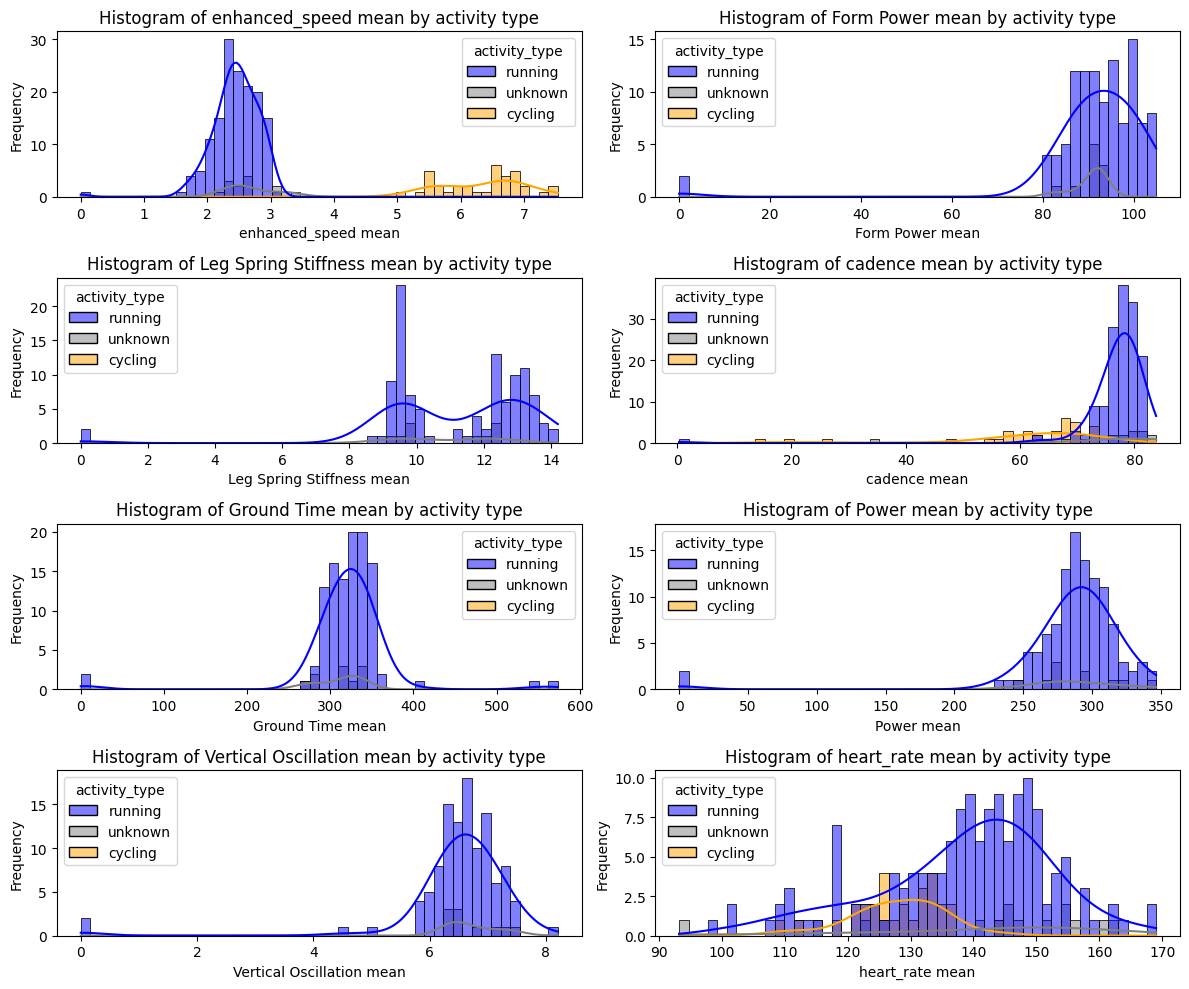

In [25]:
plt.figure(figsize=(12, 10))
for i, col in enumerate(target_columns):
    plt.subplot(4, 2, i + 1)
    sns.histplot(
        x=grouped_df[col]["mean"],
        hue=grouped_df["activity_type"],
        bins=50,
        kde=True,
        palette={"running": "blue", "cycling": "orange", "unknown": "gray"},
    )
    plt.title(f"Histogram of {col} mean by activity type")
    plt.xlabel(f"{col} mean")
    plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

In [26]:
grouped_df["activity_type"].value_counts()

activity_type
running    148
cycling     36
unknown     15
Name: count, dtype: int64

The most data is categorized by max speed. Just 15 records are not categorized.

Classify unknown activity_type using random forest.
Build features from the aggregated (max, median, mean) values and train a RandomForestClassifier on rows with known activity_type.
Then predict the activity_type for rows labelled 'unknown' and add the predictions to grouped_df.

In [28]:

# Flatten multi-index columns into feature columns as {col}_{stat}
feature_cols = []
for col in target_columns:
    for stat in metrics:
        try:
            series = grouped_df[col][stat]
        except Exception:
            continue
        name = f"{col}_{stat}"
        grouped_df[name] = series
        feature_cols.append(name)

X = grouped_df[feature_cols].astype(float)
y = grouped_df['activity_type'].astype(str)
known_mask = y != 'unknown'

# Confirm we have at least two classes to train on
if known_mask.sum() == 0 or y[known_mask].nunique() < 2:
    raise ValueError('Not enough labelled examples to train classifier. Skipping prediction.')

X_train, X_test, y_train, y_test = train_test_split(
    X[known_mask], y[known_mask], test_size=0.2, random_state=42, stratify=y[known_mask]
)
clf = RandomForestClassifier(n_estimators=200, random_state=42)
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)
print('Test accuracy:', accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))


unknown_mask = ~known_mask
# print(unknown_mask.sum())

grouped_df.loc[unknown_mask, 'activity_type_predicted'] = clf.predict(X[unknown_mask])
grouped_df.loc[unknown_mask, 'activity_type'] = grouped_df.loc[unknown_mask, 'activity_type_predicted']
print('Predicted activity_type for', unknown_mask.sum(), 'files.')


Test accuracy: 1.0
              precision    recall  f1-score   support

     cycling       1.00      1.00      1.00         7
     running       1.00      1.00      1.00        30

    accuracy                           1.00        37
   macro avg       1.00      1.00      1.00        37
weighted avg       1.00      1.00      1.00        37

Predicted activity_type for 15 files.


Check final distribution of activity_type after categorization.

In [29]:
grouped_df["activity_type"].value_counts()

activity_type
running    163
cycling     36
Name: count, dtype: int64

Assign activity type to the original dataframe.

In [30]:
activity_type_map = grouped_df["activity_type"].to_dict()
# print(activity_type_map)
df["activity_type"] = df["source_file"].map(activity_type_map)
df.head()

,cadence,distance,enhanced_altitude,enhanced_speed,fractional_cadence,heart_rate,position_lat,position_long,timestamp,source_file,Ground Time,Power,Vertical Oscillation,Air Power,Form Power,Leg Spring Stiffness,activity_type
0,74.0,1.27,258.0,1.885,0.5,103.0,504427594.0,-998947981.0,2019-07-14 17:20:28,2688518063.fit,NaN,NaN,NaN,NaN,NaN,NaN,running
1,74.0,2.21,257.8,1.959,0.5,104.0,504427557.0,-998947840.0,2019-07-14 17:20:29,2688518063.fit,NaN,NaN,NaN,NaN,NaN,NaN,running
2,74.0,3.50,257.4,1.810,0.5,104.0,504427501.0,-998947669.0,2019-07-14 17:20:30,2688518063.fit,NaN,NaN,NaN,NaN,NaN,NaN,running
3,75.0,9.10,255.0,1.791,0.5,104.0,504427404.0,-998946894.0,2019-07-14 17:20:33,2688518063.fit,NaN,NaN,NaN,NaN,NaN,NaN,running
4,75.0,11.18,254.2,1.819,0.5,104.0,504427403.0,-998946589.0,2019-07-14 17:20:34,2688518063.fit,NaN,NaN,NaN,NaN,NaN,NaN,running


Check final columns.

In [31]:
df.columns

Index(['cadence', 'distance', 'enhanced_altitude', 'enhanced_speed',
       'fractional_cadence', 'heart_rate', 'position_lat', 'position_long',
       'timestamp', 'source_file', 'Ground Time', 'Power',
       'Vertical Oscillation', 'Air Power', 'Form Power',
       'Leg Spring Stiffness', 'activity_type'],
      dtype='object')

Save the preprocessed data as a new CSV file.

In [32]:
df.to_csv("/voc/work/csv_output/preprocessed.csv", index=False)